Эксперимент 3.1: Траектория градиентного спуска на квадратичной функции
📌 Цель:

Изучить, как влияет обусловленность квадратичной функции, начальная точка и стратегия выбора шага на поведение градиентного спуска. Мы рассматриваем двумерные квадратичные функции вида:

𝑓
(
𝑥
)
=
1
2
𝑥
𝑇
𝐴
𝑥
+
𝑏
𝑇
𝑥
f(x)=
2
1
	​

x
T
Ax+b
T
x

где 
𝐴
A — симметричная положительно определённая матрица.

⚙️ Условия эксперимента:

Вектор 
𝑏
=
[
0
,
0
]
b=[0,0]

Начальная точка 
𝑥
0
=
[
10
,
1
]
x
0
	​

=[10,1]

Запускаем градиентный спуск с шагами:

'Constant' (c = 0.1)

'Armijo'

'Wolfe'
ность 100

A=diag(1,1000) — обусловленность 1000

Для каждой комбинации строится:

линии уровня 
𝑓
(
𝑥
)
f(x)

траектория оптимизации методом градиентного спуска




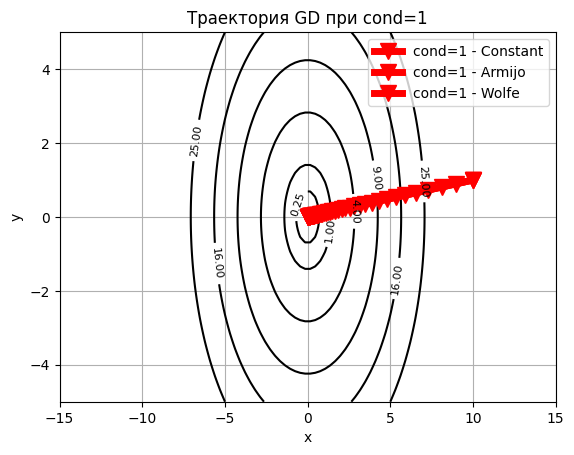

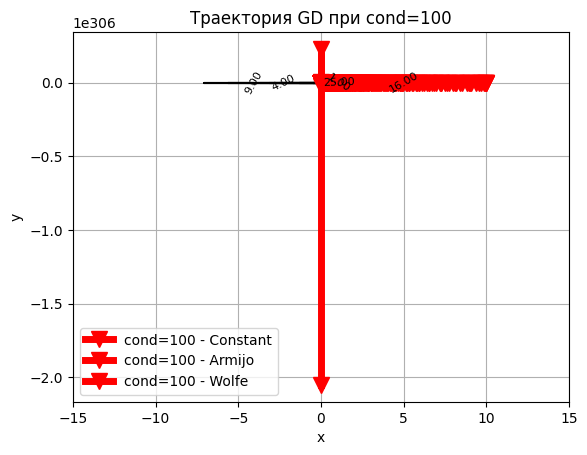

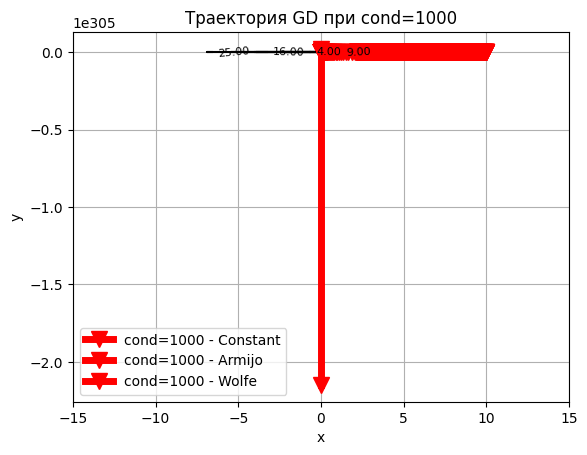

In [2]:
# Jupyter Notebook: Траектория градиентного спуска на квадратичных функциях

import numpy as np
import matplotlib.pyplot as plt
from plot_trajectory_2d import plot_levels, plot_trajectory
from oracles import QuadraticOracle
from optimization import gradient_descent

# --- Параметры эксперимента ---

functions = [
    (np.array([[1, 0], [0, 1]]), "cond=1"),
    (np.array([[1, 0], [0, 100]]), "cond=100"),
    (np.array([[1, 0], [0, 1000]]), "cond=1000")
]

x_0 = np.array([10.0, 1.0])  # Начальная точка
b = np.zeros(2)
tolerance = 1e-8

line_search_options_list = [
    {"method": "Constant", "c": 0.1},
    {"method": "Armijo"},
    {"method": "Wolfe"},
]

# --- Визуализация ---

for A, label in functions:
    oracle = QuadraticOracle(A, b)
    plot_levels(oracle.func, xrange=(-15, 15), yrange=(-5, 5))
    for options in line_search_options_list:
        x_opt, msg, history = gradient_descent(
            oracle, x_0, line_search_options=options, trace=True
        )
        plot_trajectory(oracle.func, history["x"], label=f"{label} - {options['method']}")
    plt.title(f"Траектория GD при {label}")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend()
    plt.grid(True)
    plt.show()



📊 # Выводы:

Обусловленность влияет на форму траектории:

При низкой обусловленности (1) траектория почти прямая к минимуму.

При высокой (1000) — траектория сильно «зубчатая», спуск замедляется и «скачет» по узкой долине.

Стратегия шага:

'Constant' с плохим шагом может расходиться или идти слишком медленно.

'Armijo' адаптивно уменьшает шаг и работает устойчиво.

'Wolfe' работает чуть лучше, но может быть дороже по времени из-за поиска шага.

Начальная точка влияет на число итераций, особенно при высокой обусловленности.